# ACC102 Track 4 Notebook: Multi-Stock Interaction Analysis

This notebook documents the Python workflow behind the Streamlit dashboard. It follows the assignment requirement by showing problem definition, data loading, preparation, analysis, and product-relevant outputs.

## Problem definition and intended user

**Analytical problem:** How can a retail investor compare co-movement, volatility, and short lead-lag behaviour across major technology stocks to support better watchlist and diversification decisions?

**Intended user:** A retail investor or business student who wants a visual tool for comparing several stocks at once rather than reading raw spreadsheets.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.stock_analysis import load_dataset, load_metadata, prepare_analysis_bundle

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Data loading

The data were downloaded from Yahoo Finance via `yfinance` and cached as a local CSV file so the app can run reproducibly during marking.

In [2]:
data = load_dataset(ROOT / "data/raw/us_tech_stocks.csv")
metadata = load_metadata(ROOT / "data/raw/us_tech_stocks_metadata.json")

print(json.dumps(metadata, indent=2))
data.head()

{
  "source": "Yahoo Finance via yfinance",
  "access_date": "2026-04-15",
  "row_count": 7511,
  "tickers": [
    "AAPL",
    "AMZN",
    "GOOGL",
    "META",
    "MSFT",
    "NVDA",
    "TSLA"
  ],
  "date_range": {
    "start": "2022-01-03",
    "end": "2026-04-14"
  }
}


,Date,Ticker,Open,High,Low,Close,Volume
0,2022-01-03,AAPL,174.0134,178.9550,173.8960,178.1037,104487900
1,2022-01-03,AMZN,167.5500,170.7035,166.1605,170.4045,63520000
2,2022-01-03,GOOGL,143.8659,144.6554,142.5349,143.8030,28646000
3,2022-01-03,META,335.6658,338.4242,334.5645,335.9040,14537900
4,2022-01-03,MSFT,323.7400,326.2983,318.3629,323.1608,28865100


## Data preparation and analysis logic

The Python workflow reshapes the stock data into close-price and volume matrices, calculates daily returns, indexed prices, rolling volatility, drawdown, beta, pairwise correlations, and simple lead-lag relationships.

In [3]:
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA"]

bundle = prepare_analysis_bundle(
    data,
    tickers=tickers,
    start_date="2023-01-03",
    end_date="2026-04-14",
    benchmark="MSFT",
    rolling_window=30,
    lag_days=5,
)

print("Price matrix shape:", bundle.prices.shape)
print("Return matrix shape:", bundle.daily_returns.shape)

Price matrix shape: (822, 7)
Return matrix shape: (821, 7)


## Summary table

This table provides the main performance and risk measures used in the dashboard.

In [4]:
summary = bundle.summary.copy()
summary[["Total Return", "Annualised Volatility", "Max Drawdown", "Best Day", "Worst Day", "Mean Pair Correlation"]] = summary[["Total Return", "Annualised Volatility", "Max Drawdown", "Best Day", "Worst Day", "Mean Pair Correlation"]].mul(100)
summary.rename(columns={
    "Total Return": "Total Return (%)",
    "Annualised Volatility": "Annualised Volatility (%)",
    "Max Drawdown": "Max Drawdown (%)",
    "Best Day": "Best Day (%)",
    "Worst Day": "Worst Day (%)",
    "Mean Pair Correlation": "Mean Pair Correlation (%)",
}, inplace=True)
summary

,Total Return (%),Annualised Volatility (%),Average Daily Volume,Max Drawdown (%),Best Day (%),Worst Day (%),Beta vs Benchmark,Mean Pair Correlation (%)
Ticker,,,,,,,,
NVDA,"1,274.2044",49.1718,"341,805,249.1484",-36.8810,24.3696,-16.9682,1.0572,42.9476
META,435.2645,38.5262,"17,945,428.9538",-34.1508,23.2824,-11.3348,0.8352,46.9836
GOOGL,276.6399,30.0376,"32,225,902.4331",-29.8059,10.2244,-9.5094,0.5730,45.7276
TSLA,236.9103,58.4737,"105,866,713.1387",-53.7657,22.6900,-15.4262,0.8664,38.4655
AMZN,190.1655,32.0579,"48,271,548.6618",-30.8766,11.9770,-8.9791,0.7680,50.9654
AAPL,110.2667,25.4819,"55,982,282.1168",-33.3605,15.3288,-9.2456,0.4702,42.5943
MSFT,68.3895,24.1428,"24,502,275.3041",-33.9101,10.1337,-9.9931,1.0000,48.0769


## Indexed price comparison

Indexed prices make each stock start at 100, which allows direct comparison of performance over time.

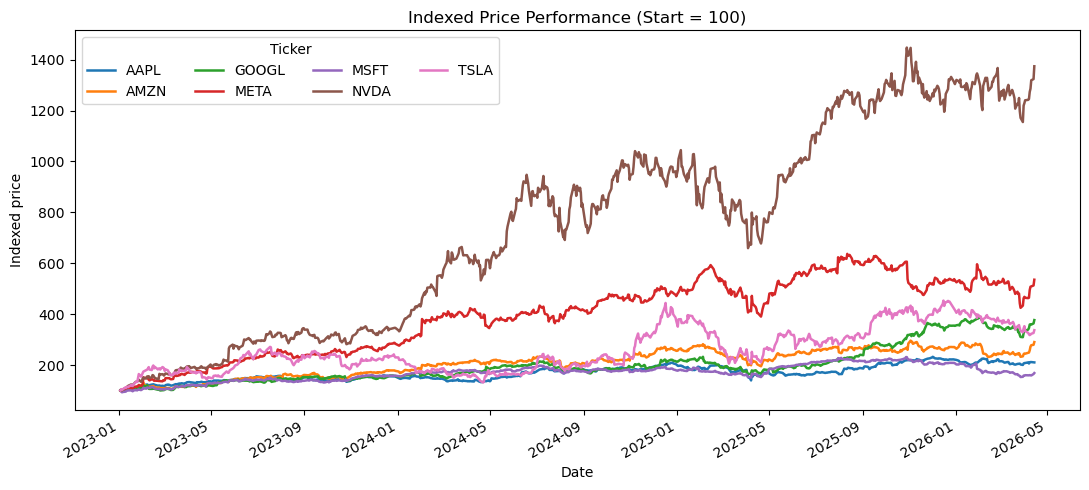

In [5]:
ax = bundle.normalized_prices.plot(figsize=(11, 5), linewidth=1.8)
ax.set_title("Indexed Price Performance (Start = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed price")
ax.legend(title="Ticker", ncol=4)
plt.tight_layout()
plt.show()

## Correlation analysis

The correlation matrix shows how strongly daily returns move together. High positive values suggest weaker diversification between the two stocks.

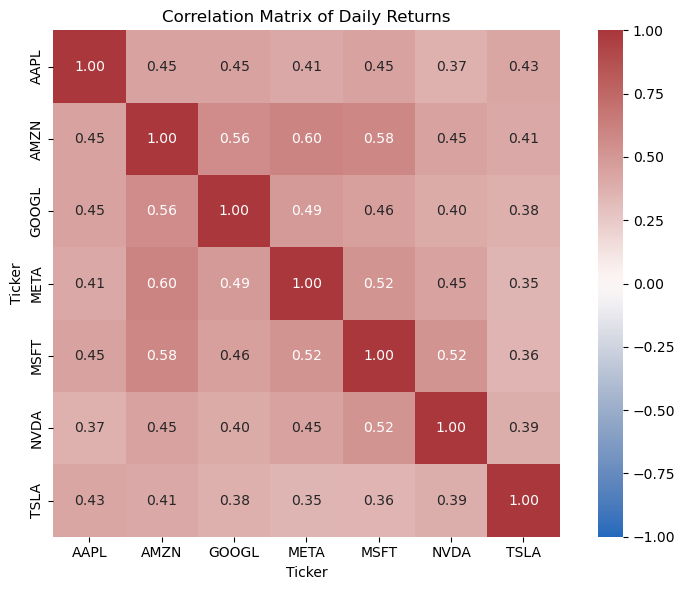

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(bundle.correlations, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix of Daily Returns")
plt.tight_layout()
plt.show()

## Pairwise interaction and lead-lag table

The lead-lag scan is exploratory. It compares same-day correlation with correlations where one stock is shifted forward by up to five trading days.

In [7]:
bundle.pairwise_relationships.head(10)

,Pair,Same-Day Correlation,Best Lead,Follower,Lag (days),Lead-Lag Correlation,Absolute Best Correlation
0,AMZN vs META,0.6050,Same day,Same day,0,0.6050,0.6050
1,AMZN vs MSFT,0.5784,AMZN,MSFT,5,0.5831,0.5831
2,AMZN vs GOOGL,0.5618,Same day,Same day,0,0.5618,0.5618
3,META vs MSFT,0.5234,META,MSFT,5,0.5314,0.5314
4,MSFT vs NVDA,0.5191,MSFT,NVDA,3,0.5251,0.5251
5,GOOGL vs META,0.4883,Same day,Same day,0,0.4883,0.4883
6,GOOGL vs MSFT,0.4605,Same day,Same day,0,0.4605,0.4605
7,AAPL vs AMZN,0.4516,AAPL,AMZN,1,0.4534,0.4534
8,AAPL vs MSFT,0.4455,AAPL,MSFT,2,0.4530,0.4530
9,AMZN vs NVDA,0.4527,Same day,Same day,0,0.4527,0.4527


## Main insights

- Nvidia had the strongest total return in the selected sample, but Tesla had the highest annualised volatility and deepest drawdown risk.
- Amazon and Meta had the strongest same-day relationship, with a daily return correlation of about 0.605.
- Meta and Tesla had the weakest relationship in this stock set, which suggests more diversification than the other pairs.
- The results should be interpreted as descriptive evidence. Correlation does not prove causation, and the short lead-lag check is not a trading model.